In [5]:
import pickle
import numpy as np
from pathlib import Path
from dataclasses import dataclass

# ── Required: define Params before unpickling so pickle can resolve the class ──
@dataclass
class Params:
    logit_pi:  np.ndarray   # (J,)
    alpha:     np.ndarray   # (J, J)
    beta:      np.ndarray   # (J, J, P)
    mu:        np.ndarray   # (J, D)
    W:         np.ndarray   # (J, D, K)
    log_sigma: np.ndarray   # (J, D)

# Load artifacts from the pickle file
artifacts_path = Path("artifacts/best_model_artefact_2 emissions.pkl")
with open(artifacts_path, 'rb') as f:
    artifacts = pickle.load(f)

print("Loaded artifacts keys:", list(artifacts.keys()))

# Extract key components
best_model = artifacts['best_model']
best_J = artifacts['best_J']

# emission_cols may be None if not saved by the training notebook;
# recover from final_cfg if available, else fall back to known column list
emission_cols = artifacts.get('emission_cols')
if emission_cols is None:
    cfg = artifacts.get('final_cfg', {})
    emission_cols = getattr(cfg, 'emission_cols', None) or cfg.get('emission_cols', None)
if emission_cols is None:
    # D=2: override_rate removed (= 1 − ai_decision_authority_share by construction)
    emission_cols = ["ai_decision_authority_share", "share_authority_esc"]
    print("⚠️  emission_cols was None in artifact — using fallback:", emission_cols)

# Also load label_map / state_order_1idx if saved in artifact
label_map        = artifacts.get('label_map')
state_order_1idx = artifacts.get('state_order_1idx')

# Create a simple namespace for data
class DataNamespace:
    pass

data = DataNamespace()

print(f"Best model loaded with J={best_J} states, D={best_model.mu.shape[1]} emissions")
print(f"Emission columns: {emission_cols}")
if label_map:
    print(f"Label map from artifact: {label_map}")


Loaded artifacts keys: ['best_model', 'best_J', 'best_res_final', 'final_cfg', 'll_total', 'k_params', 'n_obs_total', 'aic', 'bic', 'emission_cols', 'transition_cols', 'control_cols', 'label_map', 'state_order_1idx', 'y_scaler', 'x_scaler', 'z_scaler']
⚠️  emission_cols was None in artifact — using fallback: ['ai_decision_authority_share', 'share_authority_esc']
Best model loaded with J=2 states, D=2 emissions
Emission columns: ['ai_decision_authority_share', 'share_authority_esc']


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Model Selection and Parameter Estimation


In [6]:

# ============================================================
# 3. Inspect Estimated Parameters
#   - Uses best_model, best_J, emission_cols from artifact cell
#   - Emissions on original scale via artifacts["y_scaler"]
#   - Transition intercepts alpha + mean transition matrix A
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax

# Use variables loaded from artifacts (cell 1)
# best_model, best_J, emission_cols already set

# ----------------------------
# Emissions (original scale)
# ----------------------------
y_sc = artifacts["y_scaler"]
mu_orig    = y_sc.inverse_transform(best_model.mu)           # (J, D)
sigma_orig = np.exp(best_model.log_sigma) * y_sc.scale_      # (J, D)

print(f"Best model: J={best_J} hidden states, D={len(emission_cols)} emissions\n")

em_rows = []
for j in range(best_J):
    for d, col in enumerate(emission_cols):
        em_rows.append({
            "State": j + 1,
            "Variable": col,
            "Mean (orig scale)": float(mu_orig[j, d]),
            "Std (orig scale)":  float(sigma_orig[j, d]),
        })

em_df = pd.DataFrame(em_rows)
em_df["Mean (orig scale)"] = em_df["Mean (orig scale)"].round(4)
em_df["Std (orig scale)"]  = em_df["Std (orig scale)"].round(4)

print("── Emission Parameters (original scale) ──")
display(em_df)

# ----------------------------
# Initial state distribution π
# ----------------------------
pi = softmax(best_model.logit_pi)   # (J,)
print("\n── Initial State Distribution (π) ──")
for j in range(best_J):
    print(f"  π(state {j+1}) = {pi[j]:.4f}")

# ----------------------------
# Transition intercepts (logit scale) α
# ----------------------------
print("\n── Transition Intercept Matrix (α logits) ──")
alpha_df = pd.DataFrame(
    np.round(best_model.alpha, 3),
    index=[f"from {j+1}" for j in range(best_J)],
    columns=[f"to {j+1}" for j in range(best_J)]
)
display(alpha_df)

# ----------------------------
# Mean transition matrix A at mean X
# Uses data.X if already populated by the posterior cell, else skips
# ----------------------------
if hasattr(data, "X") and data.X:
    X_stack = np.stack(data.X)                            # (N, T, P)
    X_mean  = np.nanmean(X_stack[:, 1:, :], axis=(0, 1)) # (P,)
    logits_mean = (best_model.alpha
                   + np.tensordot(best_model.beta, X_mean, axes=([2], [0])))  # (J, J)
    A_mean = softmax(logits_mean, axis=1)

    print("\n── Mean Transition Matrix (A) at mean X ──")
    A_df = pd.DataFrame(
        np.round(A_mean, 4),
        index=[f"from {j+1}" for j in range(best_J)],
        columns=[f"to {j+1}" for j in range(best_J)]
    )
    display(A_df)
else:
    print("\n── Mean Transition Matrix ──")
    print("  (Run the Posterior cell first to populate data.X, then re-run this cell)")


Best model: J=2 hidden states, D=2 emissions

── Emission Parameters (original scale) ──


,State,Variable,Mean (orig scale),Std (orig scale)
0,1,ai_decision_authority_share,0.4326,0.0509
1,1,share_authority_esc,0.2213,0.0500
2,2,ai_decision_authority_share,0.3964,0.0500
3,2,share_authority_esc,0.1458,0.0429



── Initial State Distribution (π) ──
  π(state 1) = 0.7078
  π(state 2) = 0.2922

── Transition Intercept Matrix (α logits) ──


,to 1,to 2
from 1,1.216,1.241
from 2,1.122,1.178



── Mean Transition Matrix ──
  (Run the Posterior cell first to populate data.X, then re-run this cell)


## State Labelling

In [7]:
# ============================================================
# STATE LABELING  (2 states: Aversion / Appreciation)
# Requires: mu_orig, emission_cols (from prior cells)
# ============================================================

import numpy as np

# Primary labeling axis: ai_decision_authority_share
# Use emission_cols from the loaded artifacts (cell 0)
authority_idx = emission_cols.index("ai_decision_authority_share")

mu_authority = mu_orig[:, authority_idx]   # (J,)
ranked = np.argsort(mu_authority)          # ascending: ranked[0]=lowest, ranked[-1]=highest

state_aversion     = int(ranked[0]) + 1   # lowest AI authority  → Aversion
state_appreciation = int(ranked[-1]) + 1  # highest AI authority → Appreciation

label_map = {
    state_aversion:     "Aversion",
    state_appreciation: "Appreciation",
}

state_order_1idx = [state_aversion, state_appreciation]

print("\n=== STATE LABELING (2 states) ===")
print("Rule: ranked by ai_decision_authority_share")
print(f"→ State {state_aversion}  = Aversion      (lower AI authority,  μ={mu_authority[state_aversion-1]:.4f})")
print(f"→ State {state_appreciation}  = Appreciation  (higher AI authority, μ={mu_authority[state_appreciation-1]:.4f})")
print("State order for plots:", state_order_1idx)



=== STATE LABELING (2 states) ===
Rule: ranked by ai_decision_authority_share
→ State 2  = Aversion      (lower AI authority,  μ=0.3964)
→ State 1  = Appreciation  (higher AI authority, μ=0.4326)
State order for plots: [2, 1]


## Posterior State Analysis

In [8]:
# ============================================================
# 4. Posterior State Assignment (WITH STATE LABELS)
#   - Loads data from Excel, builds benchmarks, scales
#   - Defines forward-backward from scratch
#   - Runs forward-backward fresh from best_model
#   - Adds state_label via label_map
#   - Prints frequency + occupancy by state id and by label
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.special import logsumexp

# ------------------------------------------------------------------
# 4a. Helper functions needed for HMM forward-backward
# ------------------------------------------------------------------

def _softmax(z, axis=-1):
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)

def _log_softmax(z, axis=-1):
    return z - logsumexp(z, axis=axis, keepdims=True)

def _precompute(p, Y, X, Z):
    """Shared emission + transition pre-computation."""
    T, D = Y.shape
    J = p.mu.shape[0]
    means = p.mu[None, :, :] + np.einsum('jdk,tk->tjd', p.W, Z)
    residuals = Y[:, None, :] - means
    sigma2 = np.exp(2 * p.log_sigma)
    log_norm = np.sum(np.log(2 * np.pi * sigma2), axis=1)
    logB = -0.5 * (log_norm[None, :] +
                   np.sum(residuals ** 2 / sigma2[None, :, :], axis=2))
    logits_all = (p.alpha[None, :, :]
                  + np.einsum('ijp,tp->tij', p.beta, X))
    logQ_all = _log_softmax(logits_all, axis=2)
    return T, J, logB, logQ_all

def forward_backward(p, Y, X, Z):
    """Full forward-backward returning (ll, log_gamma)."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = _softmax(p.logit_pi)
    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(
            log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    ll = logsumexp(log_alpha[-1])

    log_beta = np.zeros((T, J))
    for t in reversed(range(T - 1)):
        log_beta[t] = logsumexp(
            logQ_all[t + 1] + logB[t + 1][None, :] + log_beta[t + 1][None, :],
            axis=1)

    log_gamma = log_alpha + log_beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return ll, log_gamma

# ------------------------------------------------------------------
# 4b. Load data from Excel and build sequences
# ------------------------------------------------------------------

def build_benchmarks(df):
    df = df.sort_values(["manager_id", "period_id"]).copy()
    df["kpi_operational_gap_index"] = (
        (-1.0) * df["service_level_delta"]
        + (-0.6) * df["inventory_cost_delta"]
        + (-0.4) * df["expedite_cost_delta"]
        + (-1.2) * df["error_incident_count"]
    )
    df["within_unit_temporal_benchmark"] = (
        df.groupby("manager_id")["kpi_operational_gap_index"].diff(1)
    )
    pct = df.groupby("period_id")["kpi_operational_gap_index"].rank(pct=True)
    df["horizontal_peer_benchmark"] = (pct - 0.5) * 2.0

    def ai_traj(g):
        q = g["ai_decision_authority_share"].quantile(0.30)
        base = g.loc[
            g["ai_decision_authority_share"] <= q,
            "kpi_operational_gap_index",
        ].mean()
        if np.isnan(base):
            base = g["kpi_operational_gap_index"].mean()
        return g["kpi_operational_gap_index"] - base

    df["within_unit_ai_trajectory_benchmark"] = (
        df.groupby("manager_id", group_keys=False).apply(ai_traj)
    )
    df["threshold_benchmark"] = df["recent_negative_shock"].astype(float)

    # Transparency main effect + interactions (required by v2 model)
    df["transparency_level_norm"] = df["transparency_level"].astype(float) / 3.0
    df["transparency_x_operational"] = (
        df["transparency_level_norm"] * df["kpi_operational_gap_index"]
    )
    df["transparency_x_temporal"] = (
        df["transparency_level_norm"] * df["within_unit_temporal_benchmark"]
    )
    return df


xlsx_path = Path(r"..\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx")
print(f"Loading data from: {xlsx_path.resolve()}")

df = pd.read_excel(xlsx_path, sheet_name="panel_manager_period")
df = build_benchmarks(df)

# Compute share_authority_esc from decision_episode
dec_ep = pd.read_excel(xlsx_path, sheet_name="decision_episode")
dec_ep["is_escalated"] = (dec_ep["escalation_flag"] == 1).astype(int)
esc_agg = (dec_ep
    .groupby(["manager_id", "period_id"])
    .agg(n_tasks=("episode_id", "count"),
         n_escalated=("is_escalated", "sum"))
    .reset_index())
esc_agg["share_authority_esc"] = esc_agg["n_escalated"] / esc_agg["n_tasks"]
df = df.merge(esc_agg[["manager_id", "period_id", "share_authority_esc"]],
              on=["manager_id", "period_id"], how="left")
df["share_authority_esc"] = df["share_authority_esc"].fillna(0.0)

# Column definitions matching hmm_2_emissions_v2 training notebook
emission_cols_data = ["ai_decision_authority_share", "share_authority_esc"]  # D=2

transition_cols_data = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",        # transparency main effect
    "transparency_x_operational",     # transparency × kpi gap
    "transparency_x_temporal",        # transparency × temporal benchmark
]  # P=7

control_cols_data = [
    "task_complexity_index",
    "demand_volatility",
    "supply_disruption_count",
    "forecast_accuracy_mape",
    "decision_latency_avg",
    "target_difficulty",
    "performance_pressure_index",
    "recent_negative_shock",
]  # K=8

df = df.dropna(subset=emission_cols_data + transition_cols_data + control_cols_data)

Y_list, X_list, Z_list = [], [], []
ids_list, periods_list = [], []

for mid, g in df.groupby("manager_id"):
    g = g.sort_values("period_id")
    Y = g[emission_cols_data].to_numpy(float)
    X = g[transition_cols_data].to_numpy(float)
    Z = g[control_cols_data].to_numpy(float)
    if len(Y) < 3:
        continue
    Y_list.append(Y)
    X_list.append(X)
    Z_list.append(Z)
    ids_list.append(mid)
    periods_list.append(g["period_id"].to_numpy())

# Use scalers from artifacts to transform
y_sc = artifacts["y_scaler"]
x_sc = artifacts["x_scaler"]
z_sc = artifacts["z_scaler"]

Y_list = [y_sc.transform(y) for y in Y_list]
X_list = [x_sc.transform(x) for x in X_list]
Z_list = [z_sc.transform(z) for z in Z_list]

# Populate data namespace
data.Y = Y_list
data.X = X_list
data.Z = Z_list
data.ids = ids_list
data.periods = periods_list

print(f"Managers loaded: {len(data.Y)}")
seq_lens = [len(y) for y in data.Y]
print(f"Total observations: {sum(seq_lens)}")

# ------------------------------------------------------------------
# 4c. Compute gamma (N,T,J) from forward-backward
# ------------------------------------------------------------------
J = best_J
gamma_list = []
for Y_i, X_i, Z_i in zip(data.Y, data.X, data.Z):
    _, log_g = forward_backward(best_model, Y_i, X_i, Z_i)
    gamma_list.append(np.exp(log_g))  # (T_i, J)

# Stack into (N,T,J) -- works because all managers have same T
T_len = gamma_list[0].shape[0]
gamma = np.stack(gamma_list)   # (N, T, J)
N = gamma.shape[0]

# Most likely state per (i,t), 1-indexed
v_state = np.argmax(gamma, axis=2) + 1   # (N, T)

rows = []
for i, (mid, periods_i) in enumerate(zip(data.ids, data.periods)):
    for t in range(T_len):
        s = int(v_state[i, t])
        row = {
            "manager_id": mid,
            "period_id": periods_i[t],
            "most_likely_state": s,
            "most_likely_label": label_map[s],
        }
        for j in range(J):
            row[f"posterior_state_{j+1}"] = float(gamma[i, t, j])
        rows.append(row)

posteriors = pd.DataFrame(rows)

# Save
out_path = Path("hmm_posteriors.csv")
posteriors.to_csv(out_path, index=False)
print(f"\nPosterior file saved -> {out_path.resolve()}")
print(f"Shape: {posteriors.shape}")
display(posteriors.head(10))

# ----------------------------
# State frequency (argmax) -- by state ID
# ----------------------------
print("\n-- State Frequency (argmax, by ID) --")
freq = posteriors["most_likely_state"].value_counts().sort_index()
for s, n in freq.items():
    print(f"  State {s} ({label_map[s]}): {n:,} obs ({n/len(posteriors)*100:.2f}%)")

# ----------------------------
# State frequency (argmax) -- by label
# ----------------------------
print("\n-- State Frequency (argmax, by label) --")
freq_lab = posteriors["most_likely_label"].value_counts()
for lab, n in freq_lab.items():
    print(f"  {lab}: {n:,} obs ({n/len(posteriors)*100:.2f}%)")

# ----------------------------
# Posterior occupancy (gamma-based)
# ----------------------------
print("\n-- State Occupancy (posterior mean gamma_it) --")
occ = gamma.reshape(-1, J).mean(axis=0)
for j in range(J):
    s = j + 1
    print(f"  State {s} ({label_map[s]}): {occ[j]*100:.2f}%")

# Mean posterior certainty
certainty = gamma.reshape(-1, J).max(axis=1).mean()
print(f"\nMean posterior certainty: {certainty:.3f}")


Loading data from: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx


C:\Users\Admin\AppData\Local\Temp\ipykernel_23316\1663911944.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("manager_id", group_keys=False).apply(ai_traj)


Managers loaded: 120
Total observations: 3000

Posterior file saved -> C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\data_analysis\hmm_posteriors.csv
Shape: (3000, 6)


,manager_id,period_id,most_likely_state,most_likely_label,posterior_state_1,posterior_state_2
0,M0001,2,1,Appreciation,0.977200,0.022800
1,M0001,3,1,Appreciation,0.704197,0.295803
2,M0001,4,1,Appreciation,0.952919,0.047081
3,M0001,5,1,Appreciation,0.729115,0.270885
4,M0001,6,2,Aversion,0.108410,0.891590
5,M0001,7,1,Appreciation,0.926460,0.073540
6,M0001,8,2,Aversion,0.289262,0.710738
7,M0001,9,2,Aversion,0.460043,0.539957
8,M0001,10,2,Aversion,0.103070,0.896930
9,M0001,11,1,Appreciation,0.865097,0.134903



-- State Frequency (argmax, by ID) --
  State 1 (Appreciation): 1,476 obs (49.20%)
  State 2 (Aversion): 1,524 obs (50.80%)

-- State Frequency (argmax, by label) --
  Aversion: 1,524 obs (50.80%)
  Appreciation: 1,476 obs (49.20%)

-- State Occupancy (posterior mean gamma_it) --
  State 1 (Appreciation): 50.09%
  State 2 (Aversion): 49.91%

Mean posterior certainty: 0.832


## State distribution over time

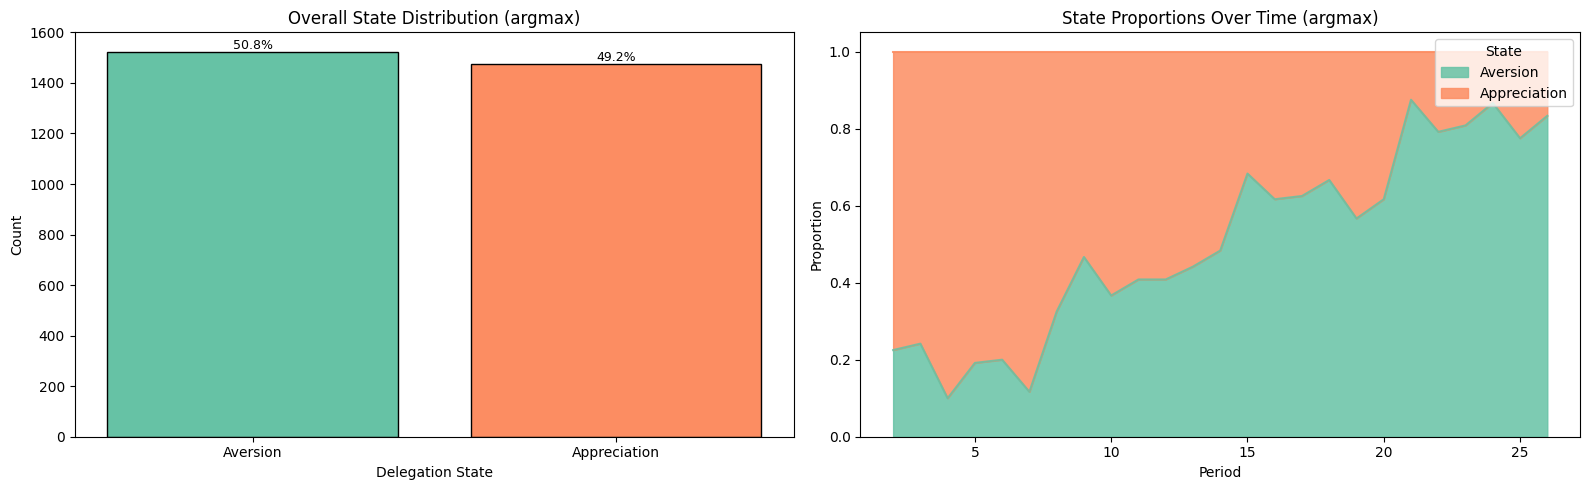

In [ ]:
# ============================================================
# 4.2a. State distribution over time (2-state version)
#   - Uses your computed label_map + state_order_1idx
#   - Ensures plots show: Aversion → Transitionary → Appreciation
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."
assert "posteriors" in globals(), "posteriors not found. Run the posterior assignment cell first."

posteriors = posteriors.copy()

# Add/refresh labels using YOUR label_map
posteriors["state_label"] = posteriors["most_likely_state"].map(label_map)

# Order labels: Aversion → Transitionary → Appreciation
label_order = [label_map[s] for s in state_order_1idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ----------------------------
# 1) Overall distribution (bar chart)
# ----------------------------
freq_labeled = (
    posteriors["state_label"]
    .value_counts()
    .reindex(label_order)
    .fillna(0)
)

axes[0].bar(
    label_order,
    freq_labeled.values,
    color=sns.color_palette("Set2", len(label_order)),
    edgecolor="k"
)
axes[0].set_xlabel("Delegation State")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall State Distribution (argmax)")

# Add percentage labels
total_n = float(freq_labeled.sum())
for i, val in enumerate(freq_labeled.values):
    pct = (val / total_n * 100.0) if total_n > 0 else 0.0
    axes[0].text(i, val, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

# ----------------------------
# 2) Proportion over time (stacked area)
# ----------------------------
pivot = (
    posteriors
    .groupby(["period_id", "state_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

pivot_pct.plot.area(
    ax=axes[1],
    stacked=True,
    alpha=0.85,
    color=sns.color_palette("Set2", len(label_order)),
)

axes[1].set_xlabel("Period")
axes[1].set_ylabel("Proportion")
axes[1].set_title("State Proportions Over Time (argmax)")
axes[1].legend(title="State", loc="upper right")

plt.tight_layout()
plt.show()
